# Stage 5b subset refit

Load the locked Stage 5b model inputs, keep a construct subset, recompile the executable SSM, and fit the reduced model. The subset is applied before compilation: dropped constructs lose their measurement indicators, incoming edges, outgoing edges, and active prior parameters.

The inference cell calls the prepared runtime directly, so it skips the Stage 5b wrapper diagnostics such as LOO. Use `INFERENCE_METHOD` to switch between the scaled `aux_gibbs` trial and the `particle_mgrad` alternative.

In [36]:
from pathlib import Path
import json
import hashlib
import logging
import sys
import time
import warnings

warnings.filterwarnings("ignore", message="IProgress not found.*")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
    datefmt="%H:%M:%S",
    stream=sys.stdout,
    force=True,
)
for logger_name in ("causal_ssm_agent", "prefect"):
    logging.getLogger(logger_name).setLevel(logging.INFO)

def find_repo_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "apps" / "data-pipeline" / "pyproject.toml").exists():
            return path
    raise RuntimeError(f"Could not find repo root above {start}")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
DATA_PIPELINE_ROOT = REPO_ROOT / "apps" / "data-pipeline"
SRC_ROOT = DATA_PIPELINE_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

import cloudpickle
import numpy as np
import jax
import jax.numpy as jnp
import polars as pl
from IPython.display import display

from causal_ssm_agent.flows.run_store import load_json, load_parquet
from causal_ssm_agent.flows.stages.stage5b.fit import run_power_scaling, run_ppc
from causal_ssm_agent.flows.stages.stage5b.subset import build_stage5b_subset_runtime
from causal_ssm_agent.models.ssm.autoreparam import AutoReparam
from causal_ssm_agent.models.ssm.inference.methods.aux_gibbs import build_aux_gibbs_pathfinder_cache
from causal_ssm_agent.utils.config import get_config

print(f"Repo root: {REPO_ROOT}")
print(f"Data pipeline root: {DATA_PIPELINE_ROOT}")

Repo root: /Users/ma9o/Desktop/causal-ssm-agent/trees/main
Data pipeline root: /Users/ma9o/Desktop/causal-ssm-agent/trees/main/apps/data-pipeline


In [37]:
# Workspace and subset controls.
WORKSPACE_ID = "DEMO"
RUN_DIR = REPO_ROOT / "data" / WORKSPACE_ID / "run"

# Use KEEP_CONSTRUCTS for an explicit retained model, or leave it None and list drops.
KEEP_CONSTRUCTS = {"affective_state", "sleep_quality", "serotonergic_exposure"}
DROP_CONSTRUCTS = set()

# Switch to "particle_mgrad" to use the local particle latent kernel instead.
INFERENCE_METHOD = "aux_gibbs"
SUBSET_LABEL = "affective_sleep_serotonergic"
OUTPUT_STEM = f"stage5b-subset-{SUBSET_LABEL}-{INFERENCE_METHOD}"

RUN_INFERENCE = True
RUN_STAGE5B_DIAGNOSTICS = False
SAVE_ARTIFACTS = True
USE_PATHFINDER_CACHE = True
REFRESH_PATHFINDER_CACHE = False
PATHFINDER_CACHE_PATH = RUN_DIR / OUTPUT_STEM / "pathfinder-cache.pkl"

COMMON_MCMC_OVERRIDES = {
    "num_warmup": 250,
    "num_samples": 250,
    "num_chains": 4,
    "seed": 0,
    "param_step_size": 0.05,
    "retain_latent_paths": False,
    "compute_latent_posterior_summary": True,
}

AUX_GIBBS_OVERRIDES = {
    "pathfinder_maxiter": 150,
    "pathfinder_num_elbo_samples": 5,
    "n_pathfinder_starts": 6,
    "pathfinder_parallel_workers": 3,
    "latent_proposal_family": "eq10_11",
    "latent_delta": 0.2,
    "latent_delta_profile": "T_minus_one_third",
    "adaptation_scheme": "simple",
    "adaptation_rate": 0.0,
    "emit_per_t_log_alpha": True,
}

PARTICLE_MGRAD_OVERRIDES = {
    "n_particles": 16,
    "backward_sampling": True,
    "latent_delta": 0.2,
    "latent_target_accept": 0.5,
    "adaptation_scheme": "simple",
    "adaptation_rate": 0.05,
    "init_method": "pathfinder",
    "pathfinder_maxiter": 150,
    "pathfinder_num_elbo_samples": 5,
    "n_pathfinder_starts": 6,
    "pathfinder_parallel_workers": 3,
}

METHOD_OVERRIDES = {
    "aux_gibbs": AUX_GIBBS_OVERRIDES,
    "particle_mgrad": PARTICLE_MGRAD_OVERRIDES,
}
if INFERENCE_METHOD not in METHOD_OVERRIDES:
    raise ValueError(f"Unsupported INFERENCE_METHOD={INFERENCE_METHOD!r}")

RUN_DIR

Path('/Users/ma9o/Desktop/causal-ssm-agent/trees/main/data/DEMO/run')

In [38]:
stage1b = load_json(str(RUN_DIR / "stage-1b.json"))
stage4 = load_json(str(RUN_DIR / "stage-4.json"))
data_for_model = load_parquet(str(RUN_DIR / "stage2-model-data.parquet"))

sampler_config = get_config().inference.to_sampler_config(method_override=INFERENCE_METHOD)
sampler_config.update(COMMON_MCMC_OVERRIDES)
sampler_config.update(METHOD_OVERRIDES[INFERENCE_METHOD])

subset = build_stage5b_subset_runtime(
    causal_spec=stage1b["causal_spec"],
    model_spec=stage4["model_spec"],
    authored_priors=stage4["authored_priors"],
    data_for_model=data_for_model,
    keep_constructs=KEEP_CONSTRUCTS,
    drop_constructs=DROP_CONSTRUCTS,
    sampler_config=sampler_config,
)

summary = pl.DataFrame(
    {
        "quantity": [
            "inference_method",
            "output_stem",
            "retained_constructs",
            "dropped_constructs",
            "retained_indicators",
            "retained_parameters",
            "timepoints",
            "manifest_columns",
            "resolved_method",
        ],
        "value": [
            INFERENCE_METHOD,
            OUTPUT_STEM,
            ", ".join(subset.retained_constructs),
            ", ".join(subset.dropped_constructs),
            str(len(subset.retained_indicators)),
            str(len(subset.retained_parameters)),
            str(len(subset.runtime.times)),
            str(len(subset.runtime.manifest_names)),
            subset.runtime.inference_structure.resolved_method,
        ],
    }
)
display(summary)

13:47:05 | WARNING | causal_ssm_agent.models.ssm_compilation | beta_serotonergic_exposure_affective_state: beta_serotonergic_exposure_affective_state is authored on 1.0d via `reference_interval_days`, but the cited evidence for serotonergic_exposure->affective_state is on 49.0d.
13:47:05 | WARNING | causal_ssm_agent.models.ssm_compilation | beta_sleep_quality_affective_state: beta_sleep_quality_affective_state is authored on 1.0d via `reference_interval_days`, but the cited evidence for sleep_quality->affective_state is on 7.0d.
13:47:05 | WARNING | causal_ssm_agent.models.ssm_compilation | drift_offdiag: beta_serotonergic_exposure_affective_state (serotonergic_exposure -> affective_state): matrix-log mismatch; exact CT coupling at 1.0d is 0.093 1/day versus the elementwise beta/dt value 0.050 1/day; logm deviation is 47% and the exact coupling is 25% of the smallest realised CT diagonal damping (0.368 1/day, rho_sleep_quality).
13:47:05 | WARNING | causal_ssm_agent.models.ssm_compilat

quantity,value
str,str
"""inference_method""","""aux_gibbs"""
"""output_stem""","""stage5b-subset-affective_sleep…"
"""retained_constructs""","""affective_state, serotonergic_…"
"""dropped_constructs""","""adherence, physical_activity, …"
"""retained_indicators""","""12"""
"""retained_parameters""","""32"""
"""timepoints""","""1588"""
"""manifest_columns""","""12"""
"""resolved_method""","""aux_gibbs"""


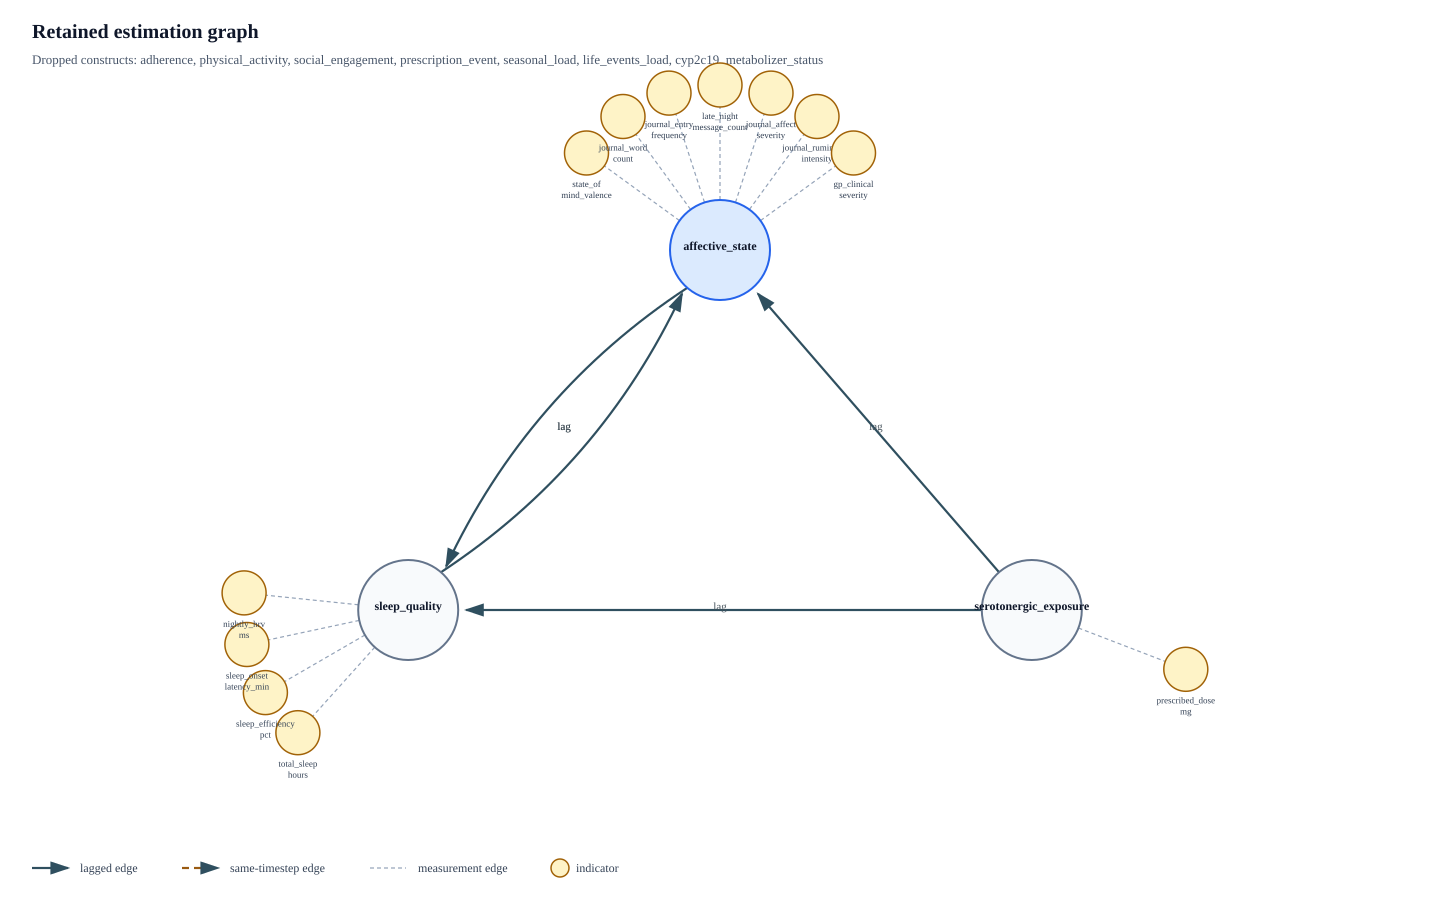

In [48]:
from html import escape
from IPython.display import SVG
import math


def _wrap_indicator_label(name: str) -> list[str]:
    words = name.split("_")
    if len(words) <= 2:
        return [name]
    mid = (len(words) + 1) // 2
    return ["_".join(words[:mid]), "_".join(words[mid:])]


def render_estimation_graph(causal_spec: dict, *, title: str = "Retained estimation graph") -> SVG:
    nodes = list(causal_spec["estimation"]["state_order"])
    edges = list(causal_spec["estimation"]["edges"])
    node_set = set(nodes)
    edges = [edge for edge in edges if edge["cause"] in node_set and edge["effect"] in node_set]
    indicators_by_construct: dict[str, list[str]] = {name: [] for name in nodes}
    for indicator in causal_spec["measurement"]["indicators"]:
        construct_name = indicator["construct_name"]
        if construct_name in indicators_by_construct:
            indicators_by_construct[construct_name].append(indicator["name"])

    width = 1440
    height = 920
    radius_x = 360
    radius_y = 240
    center_x = width / 2
    center_y = height / 2 + 30
    node_radius = 50
    indicator_radius = 22
    indicator_arc_radius = 165
    indicator_angular_step = math.radians(18)

    positions = {}
    for idx, node in enumerate(nodes):
        angle = -math.pi / 2 + 2 * math.pi * idx / max(len(nodes), 1)
        positions[node] = (
            center_x + radius_x * math.cos(angle),
            center_y + radius_y * math.sin(angle),
        )

    indicator_positions: dict[str, tuple[float, float]] = {}
    for construct_name, indicator_names in indicators_by_construct.items():
        if not indicator_names:
            continue
        cx, cy = positions[construct_name]
        outward_angle = math.atan2(cy - center_y, cx - center_x)
        n = len(indicator_names)
        for k, indicator_name in enumerate(indicator_names):
            offset = (k - (n - 1) / 2) * indicator_angular_step
            angle = outward_angle + offset
            indicator_positions[indicator_name] = (
                cx + indicator_arc_radius * math.cos(angle),
                cy + indicator_arc_radius * math.sin(angle),
            )

    paired = {(edge["cause"], edge["effect"]) for edge in edges}

    def edge_path(cause: str, effect: str) -> str:
        x1, y1 = positions[cause]
        x2, y2 = positions[effect]
        dx, dy = x2 - x1, y2 - y1
        length = max((dx * dx + dy * dy) ** 0.5, 1.0)
        sx = x1 + dx / length * node_radius
        sy = y1 + dy / length * node_radius
        ex = x2 - dx / length * (node_radius + 8)
        ey = y2 - dy / length * (node_radius + 8)
        if (effect, cause) in paired:
            mx, my = (sx + ex) / 2, (sy + ey) / 2
            curve = 52
            cx = mx - dy / length * curve
            cy = my + dx / length * curve
            return f"M {sx:.1f} {sy:.1f} Q {cx:.1f} {cy:.1f} {ex:.1f} {ey:.1f}"
        return f"M {sx:.1f} {sy:.1f} L {ex:.1f} {ey:.1f}"

    edge_svg = []
    label_svg = []
    for edge in edges:
        cause = edge["cause"]
        effect = edge["effect"]
        path_id = f"edge-{escape(cause)}-{escape(effect)}".replace("_", "-")
        stroke = "#2f4f5f" if edge.get("lagged", True) else "#9a5b12"
        dash = "" if edge.get("lagged", True) else ' stroke-dasharray="7 5"'
        edge_svg.append(
            f'<path id="{path_id}" d="{edge_path(cause, effect)}" fill="none" '
            f'stroke="{stroke}" stroke-width="2.2" marker-end="url(#arrow)"{dash}/>'
        )
        x1, y1 = positions[cause]
        x2, y2 = positions[effect]
        label_svg.append(
            f'<text x="{(x1 + x2) / 2:.1f}" y="{(y1 + y2) / 2:.1f}" '
            f'text-anchor="middle" font-size="11" fill="#44515a">'
            f'{"lag" if edge.get("lagged", True) else "same"}</text>'
        )

    measurement_edge_svg = []
    for construct_name, indicator_names in indicators_by_construct.items():
        cx, cy = positions[construct_name]
        for indicator_name in indicator_names:
            ix, iy = indicator_positions[indicator_name]
            dx, dy = ix - cx, iy - cy
            length = max((dx * dx + dy * dy) ** 0.5, 1.0)
            sx = cx + dx / length * node_radius
            sy = cy + dy / length * node_radius
            ex = ix - dx / length * indicator_radius
            ey = iy - dy / length * indicator_radius
            measurement_edge_svg.append(
                f'<line x1="{sx:.1f}" y1="{sy:.1f}" x2="{ex:.1f}" y2="{ey:.1f}" '
                f'stroke="#94a3b8" stroke-width="1.2" stroke-dasharray="4 3"/>'
            )

    indicator_svg = []
    for indicator_name, (ix, iy) in indicator_positions.items():
        indicator_svg.append(
            f'<circle cx="{ix:.1f}" cy="{iy:.1f}" r="{indicator_radius}" '
            f'fill="#fef3c7" stroke="#a16207" stroke-width="1.5"/>'
        )
        lines = _wrap_indicator_label(indicator_name)
        line_height = 11
        first_y = iy + indicator_radius + 12
        for li, line in enumerate(lines):
            indicator_svg.append(
                f'<text x="{ix:.1f}" y="{first_y + li * line_height:.1f}" '
                f'text-anchor="middle" font-size="9" fill="#334155">{escape(line)}</text>'
            )

    node_svg = []
    for node in nodes:
        x, y = positions[node]
        construct = next(
            construct for construct in causal_spec["latent"]["constructs"] if construct["name"] == node
        )
        is_outcome = bool(construct.get("is_outcome"))
        fill = "#dbeafe" if is_outcome else "#f8fafc"
        stroke = "#2563eb" if is_outcome else "#64748b"
        words = node.split("_")
        line_1 = "_".join(words[:2]) if len(words) > 2 else node
        line_2 = "_".join(words[2:]) if len(words) > 2 else ""
        node_svg.append(
            f'<circle cx="{x:.1f}" cy="{y:.1f}" r="{node_radius}" fill="{fill}" '
            f'stroke="{stroke}" stroke-width="2"/>'
            f'<text x="{x:.1f}" y="{y - (6 if line_2 else 0):.1f}" text-anchor="middle" '
            f'font-size="12" font-weight="600" fill="#0f172a">{escape(line_1)}</text>'
            + (
                f'<text x="{x:.1f}" y="{y + 12:.1f}" text-anchor="middle" '
                f'font-size="12" font-weight="600" fill="#0f172a">{escape(line_2)}</text>'
                if line_2
                else ""
            )
        )

    dropped = ", ".join(subset.dropped_constructs) or "none"
    legend_y = height - 52
    svg = f"""
    <svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">
      <defs>
        <marker id="arrow" markerWidth="10" markerHeight="10" refX="8" refY="3" orient="auto" markerUnits="strokeWidth">
          <path d="M0,0 L0,6 L9,3 z" fill="#2f4f5f" />
        </marker>
      </defs>
      <rect width="100%" height="100%" fill="#ffffff"/>
      <text x="32" y="38" font-size="20" font-weight="700" fill="#0f172a">{escape(title)}</text>
      <text x="32" y="64" font-size="13" fill="#475569">Dropped constructs: {escape(dropped)}</text>
      <g>{''.join(measurement_edge_svg)}</g>
      <g>{''.join(edge_svg)}</g>
      <g>{''.join(label_svg)}</g>
      <g>{''.join(indicator_svg)}</g>
      <g>{''.join(node_svg)}</g>
      <g transform="translate(32, {legend_y})">
        <line x1="0" y1="0" x2="36" y2="0" stroke="#2f4f5f" stroke-width="2.2" marker-end="url(#arrow)"/>
        <text x="48" y="4" font-size="12" fill="#334155">lagged edge</text>
        <line x1="150" y1="0" x2="186" y2="0" stroke="#9a5b12" stroke-width="2.2" stroke-dasharray="7 5" marker-end="url(#arrow)"/>
        <text x="198" y="4" font-size="12" fill="#334155">same-timestep edge</text>
        <line x1="338" y1="0" x2="374" y2="0" stroke="#94a3b8" stroke-width="1.2" stroke-dasharray="4 3"/>
        <text x="386" y="4" font-size="12" fill="#334155">measurement edge</text>
        <circle cx="528" cy="0" r="9" fill="#fef3c7" stroke="#a16207" stroke-width="1.5"/>
        <text x="544" y="4" font-size="12" fill="#334155">indicator</text>
      </g>
    </svg>
    """
    return SVG(svg)


render_estimation_graph(subset.causal_spec)

In [40]:
edge_rows = subset.causal_spec["estimation"]["edges"]
edge_df = pl.DataFrame(edge_rows) if edge_rows else pl.DataFrame({"cause": [], "effect": []})
parameter_df = pl.DataFrame({"parameter": list(subset.retained_parameters)})
dropped_parameter_hits = (
    parameter_df.filter(pl.col("parameter").str.contains("|".join(sorted(DROP_CONSTRUCTS))))
    if DROP_CONSTRUCTS
    else pl.DataFrame({"parameter": []})
)

display(edge_df.select([col for col in ("cause", "effect", "lagged") if col in edge_df.columns]))
display(dropped_parameter_hits)
display(parameter_df)

cause,effect,lagged
str,str,bool
"""serotonergic_exposure""","""affective_state""",true
"""serotonergic_exposure""","""sleep_quality""",true
"""sleep_quality""","""affective_state""",true
"""affective_state""","""sleep_quality""",true


parameter
null


parameter
str
"""obs_sd_gp_clinical_severity"""
"""obs_sd_journal_affect_severity"""
"""obs_sd_journal_rumination_inte…"
"""obs_sd_journal_word_count"""
"""obs_sd_state_of_mind_valence"""
…
"""lambda_journal_word_count_affe…"
"""lambda_late_night_message_coun…"
"""lambda_nightly_hrv_ms_sleep_qu…"


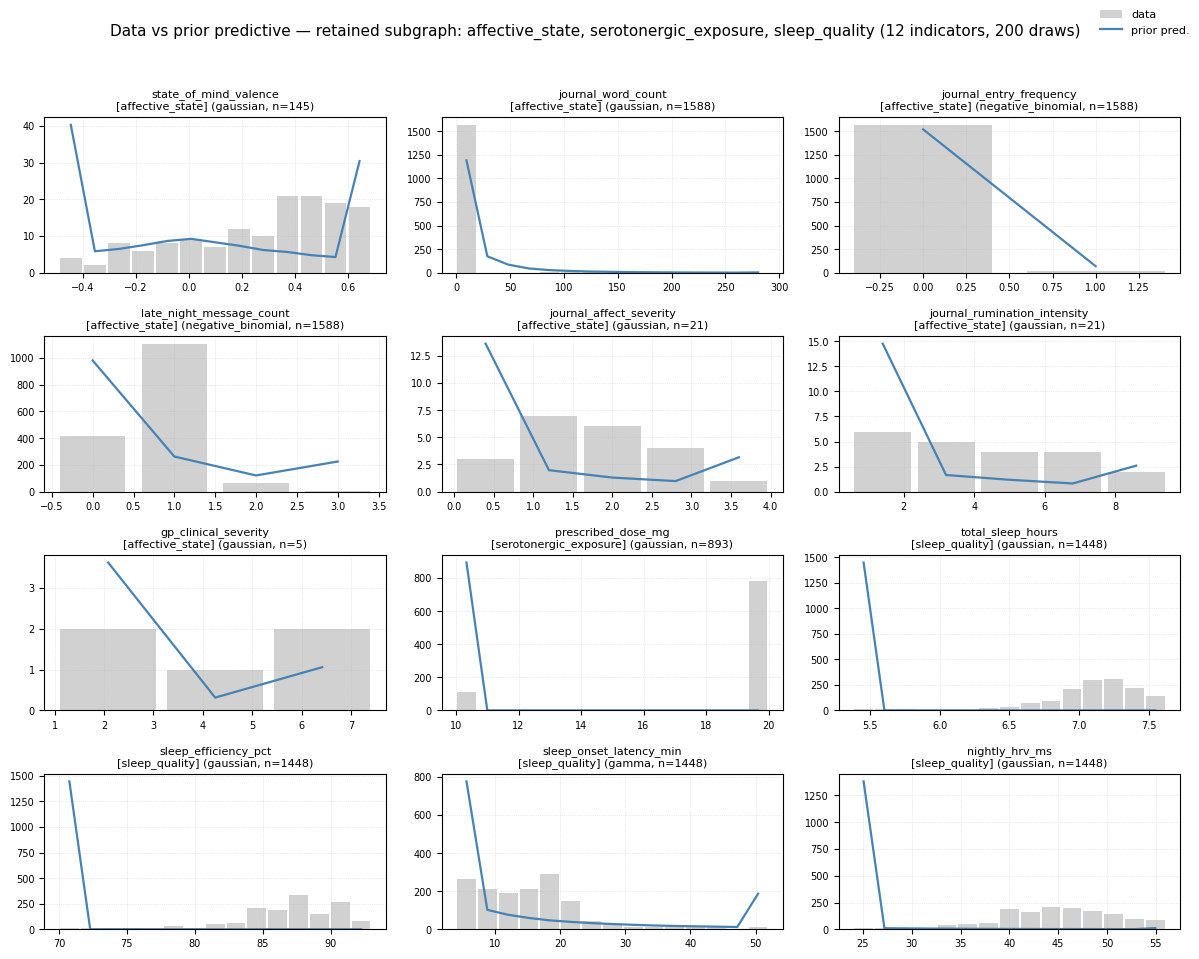

In [47]:
import matplotlib.pyplot as plt

PRIOR_PREDICTIVE_DRAWS = 200
DISCRETE_FAMILIES = {"poisson", "bernoulli", "negative_binomial", "ordered_logistic"}

prior_pp = subset.runtime.builder.sample_prior_predictive(samples=PRIOR_PREDICTIVE_DRAWS)
y_pp = np.asarray(jax.device_get(prior_pp["observations"]))
mask_pp_raw = prior_pp.get("observations_mask")
mask_pp = (
    np.asarray(jax.device_get(mask_pp_raw), dtype=bool) if mask_pp_raw is not None else None
)

manifest_index = {name: i for i, name in enumerate(subset.runtime.manifest_names)}
likelihood_by_var = {lik["variable"]: lik for lik in subset.model_spec["likelihoods"]}
construct_by_indicator = {
    indicator["name"]: indicator["construct_name"]
    for indicator in subset.causal_spec["measurement"]["indicators"]
}

# Iterate over indicators of retained constructs only, grouped by construct so the
# retained subgraph structure is visible in the plot layout.
retained_constructs = list(subset.retained_constructs)
plot_order: list[str] = []
for construct in retained_constructs:
    plot_order.extend(
        name
        for name in subset.retained_indicators
        if construct_by_indicator.get(name) == construct
    )
missing_from_runtime = [name for name in plot_order if name not in manifest_index]
if missing_from_runtime:
    raise RuntimeError(
        f"Retained indicators not found in runtime manifest: {missing_from_runtime}"
    )

n_panels = len(plot_order)
n_cols = 3
n_rows = max(1, math.ceil(n_panels / n_cols))
fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(4.0 * n_cols, 2.4 * n_rows), squeeze=False
)

for plot_idx, name in enumerate(plot_order):
    ax = axes[plot_idx // n_cols][plot_idx % n_cols]
    manifest_idx = manifest_index[name]
    construct = construct_by_indicator.get(name, "?")

    obs = (
        subset.data_for_model.filter(pl.col("indicator") == name)
        .get_column("value")
        .drop_nulls()
        .to_numpy()
        .astype(float)
    )
    n_obs = int(obs.size)

    column = y_pp[:, :, manifest_idx]
    if mask_pp is not None and mask_pp.shape == y_pp.shape:
        prior_samples = column[mask_pp[:, :, manifest_idx]]
    else:
        prior_samples = column[np.isfinite(column)]
    prior_samples = prior_samples[np.isfinite(prior_samples)]

    likelihood = likelihood_by_var.get(name, {})
    distribution = likelihood.get("distribution", "")
    is_discrete = distribution in DISCRETE_FAMILIES

    if n_obs == 0:
        ax.set_title(f"{name}\n[{construct}] (no obs)", fontsize=8)
        ax.axis("off")
        continue

    if is_discrete:
        unique_obs = np.unique(np.round(obs).astype(np.int64))
        edges = np.append(unique_obs - 0.5, unique_obs[-1] + 0.5).astype(float)
        centers = unique_obs.astype(float)
        bar_width = 0.8
    else:
        n_bins = max(1, min(15, int(np.ceil(np.sqrt(n_obs)))))
        lo = float(np.min(obs))
        hi = float(np.max(obs))
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            lo -= 0.5
            hi += 0.5
        edges = np.linspace(lo, hi, n_bins + 1)
        centers = 0.5 * (edges[:-1] + edges[1:])
        bar_width = (edges[1] - edges[0]) * 0.9

    data_counts, _ = np.histogram(obs, bins=edges)
    if prior_samples.size > 0:
        clipped_prior = np.clip(prior_samples, edges[0], edges[-1])
        prior_counts, _ = np.histogram(clipped_prior, bins=edges)
        prior_scaled = prior_counts * (n_obs / prior_samples.size)
    else:
        prior_scaled = np.zeros_like(data_counts, dtype=float)

    ax.bar(
        centers,
        data_counts,
        width=bar_width,
        color="0.55",
        alpha=0.4,
        edgecolor="none",
        label="data",
    )
    if prior_samples.size > 0:
        ax.plot(
            centers,
            prior_scaled,
            color="steelblue",
            linewidth=1.6,
            label="prior pred.",
        )

    ax.set_title(f"{name}\n[{construct}] ({distribution}, n={n_obs})", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.5)

for idx in range(n_panels, n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].axis("off")

handles = [
    plt.Rectangle((0, 0), 1, 1, fc="0.55", alpha=0.4, ec="none"),
    plt.Line2D([0], [0], color="steelblue", linewidth=1.6),
]
fig.legend(
    handles,
    ["data", "prior pred."],
    loc="upper right",
    fontsize=8,
    frameon=False,
)
fig.suptitle(
    f"Data vs prior predictive — retained subgraph: {', '.join(retained_constructs)} "
    f"({n_panels} indicators, {PRIOR_PREDICTIVE_DRAWS} draws)",
    fontsize=11,
)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

In [42]:
pathfinder_cache_record = None
pathfinder_fit_kwargs = {}
PATHFINDER_CACHE_METHODS = {"aux_gibbs", "particle_mgrad"}


def _sha256_json(payload: dict) -> str:
    return hashlib.sha256(json.dumps(payload, sort_keys=True).encode("utf-8")).hexdigest()


def _sha256_array(value) -> str:
    return hashlib.sha256(np.asarray(jax.device_get(value)).tobytes()).hexdigest()


def _resolved_pathfinder_config() -> dict:
    return {
        "seed": int(sampler_config["seed"]),
        "num_chains": int(sampler_config["num_chains"]),
        "n_ieks_iters": int(sampler_config.get("n_ieks_iters", 6)),
        "pathfinder_num_elbo_samples": int(
            sampler_config.get("pathfinder_num_elbo_samples", 20)
        ),
        "pathfinder_maxiter": int(sampler_config.get("pathfinder_maxiter", 20)),
        "n_pathfinder_starts": int(sampler_config.get("n_pathfinder_starts", 2)),
        "pathfinder_parallel_workers": sampler_config.get("pathfinder_parallel_workers"),
        "pathfinder_init_scale": sampler_config.get("pathfinder_init_scale"),
        "prior_release_scale": float(sampler_config.get("prior_release_scale", 0.05)),
    }


def _pathfinder_cache_signature() -> dict:
    return {
        "compiled_ssm_sha256": _sha256_json(subset.compiled_ssm),
        "observations_sha256": _sha256_array(subset.runtime.observations),
        "times_sha256": _sha256_array(subset.runtime.times),
        "retained_constructs": list(subset.retained_constructs),
        "retained_indicators": list(subset.retained_indicators),
        "retained_parameters": list(subset.retained_parameters),
        "pathfinder_config": _resolved_pathfinder_config(),
    }


if USE_PATHFINDER_CACHE and INFERENCE_METHOD in PATHFINDER_CACHE_METHODS:
    cache_logger = logging.getLogger("stage5b_subset.pathfinder_cache")
    cache_reparam = sampler_config.get("reparam", AutoReparam(centered=0.0))
    cache_signature = _pathfinder_cache_signature()
    should_build_cache = REFRESH_PATHFINDER_CACHE or not PATHFINDER_CACHE_PATH.exists()

    if PATHFINDER_CACHE_PATH.exists() and not REFRESH_PATHFINDER_CACHE:
        with PATHFINDER_CACHE_PATH.open("rb") as f:
            loaded_cache_record = cloudpickle.load(f)
        if loaded_cache_record["signature"] == cache_signature:
            pathfinder_cache_record = loaded_cache_record
            cache_logger.info("Loaded Pathfinder cache: %s", PATHFINDER_CACHE_PATH)
        else:
            should_build_cache = True
            cache_logger.info(
                "Ignoring stale Pathfinder cache because the subset/data/config signature changed: %s",
                PATHFINDER_CACHE_PATH,
            )
    elif REFRESH_PATHFINDER_CACHE:
        cache_logger.info("Refreshing Pathfinder cache: %s", PATHFINDER_CACHE_PATH)
    else:
        cache_logger.info("No Pathfinder cache found; building: %s", PATHFINDER_CACHE_PATH)

    if should_build_cache:
        PATHFINDER_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
        pathfinder_config = _resolved_pathfinder_config()
        cache_logger.info(
            "Building Pathfinder cache: starts=%d maxiter=%d elbo_samples=%d parallel_workers=%s",
            pathfinder_config["n_pathfinder_starts"],
            pathfinder_config["pathfinder_maxiter"],
            pathfinder_config["pathfinder_num_elbo_samples"],
            pathfinder_config["pathfinder_parallel_workers"],
        )
        pathfinder_cache = build_aux_gibbs_pathfinder_cache(
            subset.runtime.model,
            subset.runtime.observations,
            subset.runtime.times,
            num_chains=pathfinder_config["num_chains"],
            seed=pathfinder_config["seed"],
            reparam=cache_reparam,
            n_ieks_iters=pathfinder_config["n_ieks_iters"],
            pathfinder_num_elbo_samples=pathfinder_config["pathfinder_num_elbo_samples"],
            pathfinder_maxiter=pathfinder_config["pathfinder_maxiter"],
            n_pathfinder_starts=pathfinder_config["n_pathfinder_starts"],
            pathfinder_parallel_workers=pathfinder_config["pathfinder_parallel_workers"],
            pathfinder_init_scale=pathfinder_config["pathfinder_init_scale"],
            prior_release_scale=pathfinder_config["prior_release_scale"],
        )
        pathfinder_cache_record = {
            "signature": cache_signature,
            "initial_positions_override": np.asarray(
                jax.device_get(pathfinder_cache.initial_positions_override)
            ),
            "parameter_preconditioner_chol": np.asarray(
                jax.device_get(pathfinder_cache.parameter_preconditioner_chol)
            ),
            "diagnostics": pathfinder_cache.diagnostics,
        }
        with PATHFINDER_CACHE_PATH.open("wb") as f:
            cloudpickle.dump(pathfinder_cache_record, f)
        cache_logger.info("Wrote Pathfinder cache: %s", PATHFINDER_CACHE_PATH)

    pathfinder_fit_kwargs = {
        "initial_positions_override": jnp.asarray(
            pathfinder_cache_record["initial_positions_override"]
        ),
        "parameter_preconditioner_chol": jnp.asarray(
            pathfinder_cache_record["parameter_preconditioner_chol"]
        ),
        "reparam": cache_reparam,
    }
    display(
        pl.DataFrame(
            {
                "quantity": [
                    "cache_for_method",
                    "best_pathfinder_elbo",
                    "pathfinder_elbo_spread",
                    "n_pathfinder_starts_finite",
                    "initial_positions_shape",
                    "preconditioner_shape",
                ],
                "value": [
                    INFERENCE_METHOD,
                    str(pathfinder_cache_record["diagnostics"].get("best_pathfinder_elbo")),
                    str(pathfinder_cache_record["diagnostics"].get("pathfinder_elbo_spread")),
                    str(pathfinder_cache_record["diagnostics"].get("n_pathfinder_starts_finite")),
                    str(tuple(pathfinder_cache_record["initial_positions_override"].shape)),
                    str(tuple(pathfinder_cache_record["parameter_preconditioner_chol"].shape)),
                ],
            }
        )
    )
else:
    logging.getLogger("stage5b_subset.pathfinder_cache").info(
        "Pathfinder cache skipped for method=%s; inference will use method defaults.",
        INFERENCE_METHOD,
    )

13:47:35 | INFO | stage5b_subset.pathfinder_cache | Loaded Pathfinder cache: /Users/ma9o/Desktop/causal-ssm-agent/trees/main/data/DEMO/run/stage5b-subset-affective_sleep_serotonergic-aux_gibbs/pathfinder-cache.pkl


quantity,value
str,str
"""cache_for_method""","""aux_gibbs"""
"""best_pathfinder_elbo""","""-18407.35577905268"""
"""pathfinder_elbo_spread""","""847.4538733684603"""
"""n_pathfinder_starts_finite""","""6"""
"""initial_positions_shape""","""(4, 32)"""
"""preconditioner_shape""","""(32, 32)"""


In [43]:
fitted = None
if RUN_INFERENCE:
    runtime = subset.runtime
    print(
        f"Starting subset {INFERENCE_METHOD} fit via prepared runtime; Stage 5b wrapper diagnostics are skipped.",
        flush=True,
    )
    start = time.perf_counter()
    result = runtime.builder.fit_prepared(
        runtime.observations,
        runtime.times,
        **pathfinder_fit_kwargs,
    )
    elapsed = time.perf_counter() - start
    samples = result.get_samples()
    n_samples = (
        int(next(iter(samples.values())).shape[0])
        if isinstance(samples, dict) and samples
        else 0
    )
    fitted = {
        "fitted": True,
        "inference_type": result.method,
        "n_samples": n_samples,
        "duration_seconds": elapsed,
        "result": result,
        "builder": runtime.builder,
        "runtime": runtime,
        "times": runtime.times,
        "mcmc_diagnostics": None,
        "svi_diagnostics": None,
        "smc_diagnostics": None,
        "loo_diagnostics": None,
        "posterior_marginals": None,
        "posterior_pairs": None,
    }
    print(
        f"fitted={fitted.get('fitted')} method={fitted.get('inference_type')} "
        f"samples={fitted.get('n_samples')} elapsed={elapsed:.1f}s"
    )
else:
    print(f"RUN_INFERENCE=False. Set it to True in the config cell to start {INFERENCE_METHOD}.")

Starting subset aux_gibbs fit via prepared runtime; Stage 5b wrapper diagnostics are skipped.
13:47:35 | INFO | causal_ssm_agent.models.ssm.inference.methods.aux_gibbs | aux_gibbs entry: chains=4 warmup=250 samples=250 T=1588 n_manifest=12 init_method=pathfinder parallel_filter=True latent_kernel=kalman parameter_kernel=mala auto_preconditioner_method=pathfinder
13:47:35 | INFO | causal_ssm_agent.models.ssm.inference.methods.aux_gibbs | phase 1/6: building auxiliary Kalman bundle...
13:47:36 | INFO | causal_ssm_agent.models.ssm.inference.methods.aux_gibbs | phase 1/6: bundle ready in 0.0s (dim=32, public_sites=14)
13:47:36 | INFO | causal_ssm_agent.models.ssm.inference.methods.aux_gibbs | phase 2/6: init positions = user_provided override (0.0s)
13:47:36 | INFO | causal_ssm_agent.models.ssm.inference.methods.aux_gibbs | phase 3/6: preconditioner = caller-provided (skipped, 0.0s)
13:47:36 | INFO | causal_ssm_agent.models.ssm.inference.methods.aux_gibbs | phase 4/6: building latent + par

In [44]:
latent_accept_diagnostics = None
if fitted is not None:
    result = fitted["result"]
    method_key = result.method
    method_diag = result.diagnostics.get(method_key, {})
    summary_keys = [
        "latent_accept_rate",
        "latent_update_fraction",
        "parameter_accept_rate",
        "final_latent_delta",
        "final_param_step_size",
        "latent_proposal_family",
        "latent_delta_profile",
        "n_particles",
        "backward_sampling",
        "adaptation_scheme",
    ]
    summary_rows = []
    for key in summary_keys:
        if key not in method_diag:
            continue
        value = method_diag[key]
        arr = np.asarray(value) if not isinstance(value, (str, int, float, bool, type(None))) else value
        if hasattr(arr, "shape") and arr.shape:
            rendered = f"mean={float(np.nanmean(arr)):.4g}, shape={tuple(arr.shape)}"
        else:
            rendered = str(value)
        summary_rows.append({"quantity": key, "value": rendered})
    if summary_rows:
        display(pl.DataFrame(summary_rows))

    extra = result.diagnostics["mcmc"].get_extra_fields(group_by_chain=True)
    per_t_names = [
        "log_alpha_per_t",
        "log_alpha_obs_per_t",
        "log_alpha_fwd_minus_rev_per_t",
        "log_alpha_q_per_t",
    ]
    available = [name for name in per_t_names if name in extra]
    if available:
        rows = []
        for name in available:
            arr = np.asarray(extra[name])
            if arr.ndim < 3:
                rows.append(
                    {
                        "term": name,
                        "shape": str(tuple(arr.shape)),
                        "mean": float(arr.mean()),
                        "p05": float(np.quantile(arr.reshape(-1), 0.05)),
                        "min_timepoint": None,
                        "min_time": None,
                        "min_mean": None,
                    }
                )
                continue
            per_t_mean = arr.mean(axis=(0, 1))
            worst_idx = int(per_t_mean.argmin())
            rows.append(
                {
                    "term": name,
                    "shape": str(tuple(arr.shape)),
                    "mean": float(arr.mean()),
                    "p05": float(np.quantile(arr.reshape(-1), 0.05)),
                    "min_timepoint": worst_idx,
                    "min_time": float(subset.runtime.times[worst_idx]),
                    "min_mean": float(per_t_mean[worst_idx]),
                }
            )
        latent_accept_diagnostics = pl.DataFrame(rows).sort("min_mean", nulls_last=True)
        display(latent_accept_diagnostics)

        log_alpha = np.asarray(extra["log_alpha_per_t"])
        total_log_alpha = log_alpha.sum(axis=2).reshape(-1)
        display(
            pl.DataFrame(
                {
                    "quantile": ["min", "p01", "p05", "p50", "p95", "max"],
                    "total_log_alpha": [
                        float(np.min(total_log_alpha)),
                        float(np.quantile(total_log_alpha, 0.01)),
                        float(np.quantile(total_log_alpha, 0.05)),
                        float(np.quantile(total_log_alpha, 0.50)),
                        float(np.quantile(total_log_alpha, 0.95)),
                        float(np.max(total_log_alpha)),
                    ],
                }
            )
        )

        obs = np.asarray(subset.runtime.observations)
        manifest = list(subset.runtime.manifest_names)
        per_t_mean = log_alpha.mean(axis=(0, 1))
        worst = np.argsort(per_t_mean)[:12]
        rows = []
        for idx in worst:
            observed = [manifest[j] for j, value in enumerate(obs[idx]) if not np.isnan(value)]
            rows.append(
                {
                    "timepoint": int(idx),
                    "time": float(subset.runtime.times[idx]),
                    "log_alpha_mean": float(per_t_mean[idx]),
                    "n_obs": len(observed),
                    "observed": ", ".join(observed[:8]),
                }
            )
        display(pl.DataFrame(rows))
    else:
        print(f"No per-time latent log-alpha fields found for method={method_key}.")
else:
    print("Run inference first to inspect latent acceptance diagnostics.")

quantity,value
str,str
"""latent_accept_rate""","""0.0"""
"""parameter_accept_rate""","""0.0"""
"""final_latent_delta""","""mean=0.01714, shape=(4,)"""
"""final_param_step_size""","""mean=0.05, shape=(4,)"""
"""latent_proposal_family""","""eq10_11"""
"""latent_delta_profile""","""T_minus_one_third"""
"""adaptation_scheme""","""simple"""


No per-time latent log-alpha fields found for method=aux_gibbs.


In [45]:
power_scaling = None
ppc = None
if fitted is not None and RUN_STAGE5B_DIAGNOSTICS:
    power_scaling = run_power_scaling.fn(fitted)
    ppc = run_ppc.fn(fitted)
    display(power_scaling)
    display(ppc)
else:
    print("Diagnostics skipped. Set RUN_STAGE5B_DIAGNOSTICS=True after fitting to run them.")

Diagnostics skipped. Set RUN_STAGE5B_DIAGNOSTICS=True after fitting to run them.


In [46]:
if SAVE_ARTIFACTS:
    out_dir = RUN_DIR / OUTPUT_STEM
    out_dir.mkdir(parents=True, exist_ok=True)
    (out_dir / "subset-causal-spec.json").write_text(json.dumps(subset.causal_spec), encoding="utf-8")
    (out_dir / "subset-model-spec.json").write_text(json.dumps(subset.model_spec), encoding="utf-8")
    (out_dir / "subset-compiled-ssm.json").write_text(json.dumps(subset.compiled_ssm), encoding="utf-8")
    if fitted is not None:
        with (out_dir / "subset-fitted-result.pkl").open("wb") as f:
            cloudpickle.dump(fitted, f)
    print(out_dir)
else:
    print("SAVE_ARTIFACTS=False. Set it to True to persist subset specs and fitted output.")

/Users/ma9o/Desktop/causal-ssm-agent/trees/main/data/DEMO/run/stage5b-subset-affective_sleep_serotonergic-aux_gibbs
